<a href="https://colab.research.google.com/github/gmeghana451/forage-midas/blob/flow/origin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Create a sample dataset
data = {
    "image_filename": ["/content/ultrasound_1.jpg", "/content/ultrasound_2.jpg", "/content/ultrasound_3.jpg"],
    "x1": [120, 100, 130],  # BPD X-coordinates
    "y1": [150, 140, 160],  # BPD Y-coordinates
    "x2": [200, 210, 220],  # OFD X-coordinates
    "y2": [180, 190, 200]   # OFD Y-coordinates
}

# Convert the dictionary into a DataFrame
df = pd.DataFrame(data)

# Save it as a CSV file in Colab
csv_file_path = "/content/annotations.csv"
df.to_csv(csv_file_path, index=False)

print(f"Sample CSV file created: {csv_file_path}")

# Display the first few rows of the dataset
print(df.head())


Sample CSV file created: /content/annotations.csv
              image_filename   x1   y1   x2   y2
0  /content/ultrasound_1.jpg  120  150  200  180
1  /content/ultrasound_2.jpg  100  140  210  190
2  /content/ultrasound_3.jpg  130  160  220  200


In [ ]:
import pandas as pd

# Load and check the CSV file
df_check = pd.read_csv("/content/annotations.csv")
print(df_check.head())


              image_filename   x1   y1   x2   y2
0  /content/ultrasound_1.jpg  120  150  200  180
1  /content/ultrasound_2.jpg  100  140  210  190
2  /content/ultrasound_3.jpg  130  160  220  200


In [ ]:
from google.colab import files
files.download("/content/annotations.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import os

# Create images directory if it doesn't exist
os.makedirs("/content/images", exist_ok=True)

# Upload images
uploaded = files.upload()

# Move uploaded images to the images folder
for filename in uploaded.keys():
    os.rename(filename, f"/content/images/{filename}")

print("Images uploaded successfully!")


Saving 9_HC.png to 9_HC.png
Saving 9_HC_Annotation.png to 9_HC_Annotation.png
Saving 98_HC_Annotation.png to 98_HC_Annotation.png
Saving 99_HC.png to 99_HC.png
Saving 99_HC_Annotation.png to 99_HC_Annotation.png
Saving 990_HC.png to 990_HC.png
Saving 990_HC_Annotation.png to 990_HC_Annotation.png
Saving 991_HC.png to 991_HC.png
Saving 991_HC_Annotation.png to 991_HC_Annotation.png
Images uploaded successfully!


In [ ]:
import os

image_dir = "/content/images"

# List uploaded files
image_files = os.listdir(image_dir)
print(f"Total images uploaded: {len(image_files)}")
print("Sample images:", image_files[:5])  # Show first 5 images


Total images uploaded: 9
Sample images: ['990_HC_Annotation.png', '98_HC_Annotation.png', '99_HC.png', '991_HC.png', '990_HC.png']


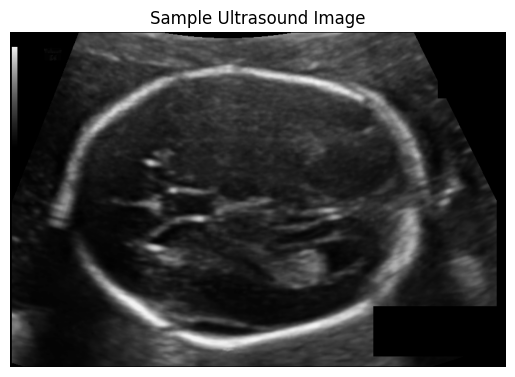

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

# Ensure image_dir is correct
image_dir = "/content/images"  # Or wherever your images are stored

# Load a sample image - check for file existence
sample_image_path = os.path.join(image_dir, "ultrasound_1.jpg")

# Check if the file exists before loading
if os.path.exists('/content/ultrasound_1.jpg'):
    image = cv2.imread('/content/ultrasound_2.jpg')

    # Check if image loading was successful
    if image is not None:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

        # Display the image
        plt.imshow(image)
        plt.axis("off")
        plt.title("Sample Ultrasound Image")
import cv2
import matplotlib.pyplot as plt
import os

# Ensure image_dir is correct
image_dir = "/content/images"  # Or wherever your images are stored

# Load a sample image - check for file existence
sample_image_path = os.path.join(image_dir, "ultrasound_1.jpg")

# Check if the file exists before loading
if os.path.exists('/content/ultrasound_1.jpg'):
    image = cv2.imread('/content/ultrasound_1.jpg')

    # Check if image loading was successful
    if image is not None:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

        # Display the image
        plt.imshow(image)
        plt.axis("off")
        plt.title("Sample Ultrasound Image")
        plt.show()
    else:
        print(f"Error: Could not load image from {'/content/ultrasound_1.jpg'}")
else:
    print(f"Error: Image file not found at {'/content/ultrasound_1.jpg'}")

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import cv2
import os
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array


In [ ]:
# Define paths
image_dir = "/content/images"
annotation_file = "/content/annotations.csv"

# Load the CSV file
df = pd.read_csv(annotation_file)

# Display the first few rows
print(df.head())


              image_filename   x1   y1   x2   y2
0  /content/ultrasound_1.jpg  120  150  200  180
1  /content/ultrasound_2.jpg  100  140  210  190
2  /content/ultrasound_3.jpg  130  160  220  200


In [ ]:
# Define image size
IMG_SIZE = 128  # Resize images to 128x128

# Function to load and preprocess images
def load_image(image_path):
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))  # Load and resize image
    img = img_to_array(img) / 255.0  # Normalize pixel values
    return img

# Prepare dataset
X = []  # Images
y = []  # Landmark coordinates

for index, row in df.iterrows():
    image_path = os.path.join(image_dir, row["image_filename"])

    if os.path.exists(image_path):
        img = load_image(image_path)
        X.append(img)
        y.append([row["x1"], row["y1"], row["x2"], row["y2"]])  # Landmark coordinates
    else:
        print(f"Image {row['image_filename']} not found!")

# Convert to NumPy arrays
X = np.array(X)
y = np.array(y)

print(f"Dataset loaded: {X.shape} images, {y.shape} labels")


Dataset loaded: (3, 128, 128, 3) images, (3, 4) labels


In [ ]:
# Define a CNN model for landmark detection
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(4, activation='linear')  # Output layer (x1, y1, x2, y2)
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

# Model summary
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.model_selection import train_test_split

# Split dataset (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=16)


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - loss: 30070.7246 - mae: 168.7181 - val_loss: 26130.0312 - val_mae: 159.1985
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 28780.0645 - mae: 165.3418 - val_loss: 24431.1211 - val_mae: 154.2681
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - loss: 26947.9785 - mae: 160.3274 - val_loss: 22015.7617 - val_mae: 146.8165
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - loss: 24362.4727 - mae: 152.7950 - val_loss: 18821.3594 - val_mae: 136.0327
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - loss: 20955.7383 - mae: 141.9289 - val_loss: 14841.8066 - val_mae: 120.7571
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - loss: 16727.5625 - mae: 126.6710 - val_loss: 10377.7246 - val_mae: 100.1504
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - loss: 11949.2383 - mae: 106.1450 - val_loss: 5995.0986 - val_mae: 73.0263
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - loss: 7158.7437 - mae: 79.2251 - val_loss: 2769.3052 - val_m

In [ ]:
# Evaluate the model
val_loss, val_mae = model.evaluate(X_val, y_val)
print(f"Validation Loss: {val_loss:.2f}, MAE: {val_mae:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 5053.4873 - mae: 56.9787
Validation Loss: 5053.49, MAE: 56.98


In [ ]:
# Load a test image
test_image_path = '/content/ultrasound_1.jpg'
test_img = load_image(test_image_path)

# Predict
predicted_landmarks = model.predict(np.expand_dims(test_img, axis=0))

# Show result
print(f"Predicted BPD & OFD landmarks: {predicted_landmarks[0]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Predicted BPD & OFD landmarks: [ 94.25204 191.07869 329.98514 211.10301]


In [ ]:
import matplotlib.pyplot as plt

def plot_landmarks(image_path, landmarks):
    """Function to plot predicted landmarks on the ultrasound image."""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    plt.figure(figsize=(5, 5))
    plt.imshow(img)

    # Extract predicted landmark coordinates
    x1, y1, x2, y2 = landmarks

    # Plot points
    plt.scatter([x1, x2], [y1, y2], color='red', marker='o', s=100, label="Predicted Points")

    plt.legend()
    plt.axis("off")
    plt.title("Predicted BPD & OFD Landmarks")
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


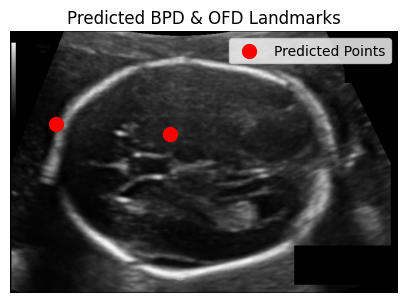

In [ ]:
# Choose a test image
test_image_path = '/content/ultrasound_1.jpg'

# Load and preprocess the image
test_img = load_image(test_image_path)

# Predict landmark points
predicted_landmarks = model.predict(np.expand_dims(test_img, axis=0))[0]  # Get first prediction

# Display the image with predicted landmarks
plot_landmarks(test_image_path, predicted_landmarks)


In [ ]:
# Evaluate the model on the validation data
val_loss, val_mae = model.evaluate(X_val, y_val)
print(f"Validation Loss: {val_loss}")
print(f"Validation MAE: {val_mae}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 27218.7422 - mae: 162.2126
Validation Loss: 27218.7421875
Validation MAE: 162.2125701904297


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


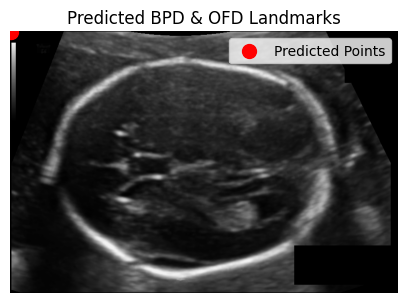

In [ ]:
# Choose a sample test image
sample_image_path = '/content/ultrasound_1.jpg'

# Load and preprocess the image
sample_img = load_image(sample_image_path)

# Predict landmarks for the sample image
predicted_landmarks = model.predict(np.expand_dims(sample_img, axis=0))[0]

# Plot the image with predicted and true landmarks
plot_landmarks(sample_image_path, predicted_landmarks)


In [ ]:
# Save the model to disk
model.save("/content/landmark_detection_model.h5")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


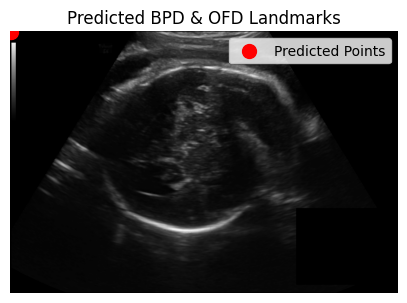

In [ ]:
# Example of testing with new ultrasound images
new_image_path = '/content/ultrasound _4.jpg'
new_img = load_image(new_image_path)

# Predict landmarks for the new image
predictions = model.predict(np.expand_dims(new_img, axis=0))[0]

# Visualize predicted landmarks
plot_landmarks(new_image_path, predictions)


In [ ]:
import matplotlib.pyplot as plt

def plot_landmarks(image_data, landmarks):  # Changed 'image_path' to 'image_data'
    """Function to plot predicted landmarks on the ultrasound image."""
    # img = cv2.imread(image_path)  # Remove this line - No need to read, we already have image data
    img = image_data  # Now 'img' is the NumPy array representing the image

    # If the image data is normalized (0-1), scale it to 0-255
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)  # Convert to uint8 if needed

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB if necessary
    plt.figure(figsize=(5, 5))
    plt.imshow(img)


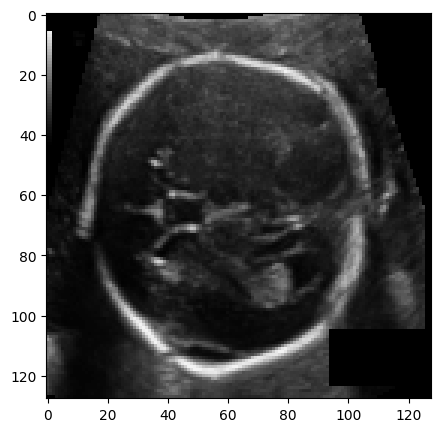

In [ ]:
plot_landmarks(sample_image, pred_landmarks)

In [ ]:
# Save the model
model.save("/content/final_landmark_detection_model.h5")
